In [3]:
from pathlib import Path
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
import json
import pandas as pd
import re
from glob import glob
import math

## PASTIS 

**PASTIS (Panoptic Agriculture Satellite Time Series)** es un dataset de series temporales satelitales orientado a agricultura.  
Cada **parche** (patch) es un recorte espacial pequeño observado múltiples veces en el tiempo, con:
- **Imagen multiespectral Sentinel-2** (carpeta `DATA_S2`): cubo 4D por parche con forma típica `(T, C, H, W)`  
  (T=fechas, C=bandas; permite calcular índices como NDVI/NDWI/NDBI).
- **Anotaciones** (carpetas `ANNOTATIONS` / `INSTANCE_ANNOTATIONS`):  
  - **Semántica** por píxel (tipo de cultivo).  
  - **Instancias** (parcelas/objetos) y zonas.  
  - IDs de parcela por píxel.

### ¿Qué contiene `metadata.geojson`?

Es un **FeatureCollection** geoespacial: cada *feature* corresponde a **un parche**.  
De cada feature tomamos solo `properties` y lo convertimos a una tabla (`metadata_df`), donde:
- **Cada fila = 1 parche** (unidad espacial).
- **Cada columna = 1 atributo** de ese parche (metadato).

Campos habituales :
- `ID_PATCH`: **identificador numérico** del parche. Permite vincular con archivos como  
  `DATA_S2/S2_{ID_PATCH}.npy` y `ANNOTATIONS/TARGET_{ID_PATCH}.npy`.
- `dates-S2`: diccionario `{t: "YYYY-MM-DD"}` que mapea el **índice temporal `t`** de `DATA_S2` a su **fecha real de adquisición** (clave normalmente como texto).  
  Útil para pasar de *t* → **mes** o **estación** en tus gráficas.
- `set` / `split` / `fold`: indican **partición experimental** (train/val/test o k-fold).
- Otros posibles: región, número de parcelas en el parche (`n_parcels`), indicadores de nubes, etc.

> **Interpretación práctica:**  
> - La tabla es el **puente** entre el espacio/tiempo y tus datos numéricos.  
> - De aquí obtienes **qué parches existen**, **a qué partición pertenecen** y **en qué fechas** fueron observados.  
> - Con `ID_PATCH` enlazas a los cubos multiespectrales; con `dates-S2` pones **fecha/mes** al eje *X*.

### ¿Por qué convertir `properties` a DataFrame?

- Facilita **explorar la estructura** (número de parches, tipos de columnas, valores faltantes).
- Permite **filtrar** rápidamente (p. ej., solo *train*, o solo parches con cierto número de fechas).
- Habilita **joins** limpios con tus resultados (ej. promedios NDVI por `t` → agregar columna de fecha/mes desde `dates-S2`).


In [5]:

# Ruta al GeoJSON de metadatos de PASTIS
metadata_path = "../PASTIS/PASTIS/metadata.geojson"

# 1) Leer el GeoJSON en memoria
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata_json = json.load(f)

# 2) Extraer solo los "properties" de cada parche (feature)
records = [feat["properties"] for feat in metadata_json["features"]]

# 3) Pasar a DataFrame: cada fila = parche, cada columna = atributo del metadato
metadata_df = pd.DataFrame(records)

# 4) Vista rápida de la estructura de los metadatos
print("Forma (filas, columnas):", metadata_df.shape)
display(metadata_df.dtypes)       # tipos de cada columna
metadata_df.head()                # primeras filas


Forma (filas, columnas): (2433, 7)


Fold              int64
ID_PATCH          int64
N_Parcel          int64
Parcel_Cover    float64
TILE             object
dates-S2         object
id               object
dtype: object

,Fold,ID_PATCH,N_Parcel,Parcel_Cover,TILE,dates-S2,id
0,1,10000,119,0.808032,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10000
1,2,10001,111,0.501986,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10001
2,4,10002,131,0.638722,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10002
3,5,10003,75,0.866824,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10003
4,4,10004,46,0.204906,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10004


In [14]:
metadata_df['TILE'].value_counts()

TILE
t31tfm    723
t31tfj    623
t32ulu    556
t30uxv    531
Name: count, dtype: int64

# Parches Sentinel-2 

**Qué es este archivo:**  
Cada `.npy` en `DATA_S2` es un **cubo multiespectral temporal** de Sentinel-2 para un parche del dataset.  
El arreglo tiene 4 ejes (orden depende de cómo se guardó ese set). Habitualmente hay:
- **Bandas espectrales** (típicamente 10 bandas de S2).
- **Tiempos** (múltiples fechas/observaciones del mismo parche).
- **Altura** (pixeles Y) y **Anchura** (pixeles X).

In [6]:
# # Cargar el archivo .npy
chosen_img = 'S2_10000.npy'
data = np.load(f'../PASTIS/PASTIS/DATA_S2/{chosen_img}') 

# Mostrar información básica
print("Forma de los datos:", data.shape)

Forma de los datos: (43, 10, 128, 128)


In [7]:
# Mostrar el nombre del archivo seleccionado
print(chosen_img)

# Extraer el número de parche (ID) a partir del nombre del archivo .npy
# Ejemplo: "S2_10174.npy"  ->  ID_PATCH = 10174
id_patch = re.search(r'S2_(\d+)', chosen_img).group(1)
print(id_patch)

# Filtrar en el DataFrame de metadatos el registro que corresponde a ese parche
# Cada fila del metadata describe un parche: aquí vemos solo el que coincide con chosen_img
patch_data = metadata_df[metadata_df['ID_PATCH'] == int(id_patch)]
n_parcelas = patch_data['N_Parcel'].values[0]
print(f'En el parche {id_patch} de 1 km², hay {n_parcelas} parcelas agrícolas distintas.')
patch_data

S2_10000.npy
10000
En el parche 10000 de 1 km², hay 119 parcelas agrícolas distintas.


,Fold,ID_PATCH,N_Parcel,Parcel_Cover,TILE,dates-S2,id
0,1,10000,119,0.808032,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10000


## Visualización temporal (RGB) de un parche Sentinel-2

**Qué ves aquí**  
- Una **serie temporal** del mismo parche: cada panel corresponde a un **instante t** distinto.  
- El título de cada panel muestra **t** y la **fecha real** de adquisición (desde metadata).  
- Es una vista rápida de **calidad** y **dinámica**: vegetación, suelo expuesto, presencia de nubes, cambios agrícolas.

**De dónde salen los datos**  
- `data` es el cubo multiespectral del parche con forma **(T, C, H, W)**:
  - **T** = número de fechas observadas,  
  - **C** = bandas espectrales Sentinel-2 (ORDER_10 típico),  
  - **H, W** = dimensiones del parche en píxeles.  
- `dates_dict` mapea cada **t** a una **fecha** (formato `YYYY-MM-DD`) obtenida de `metadata.geojson`.

**Cómo se arma el RGB**  
- Se toman 3 bandas como **R-G-B**; por defecto `(2, 1, 0)` ≈ **B4 (Rojo), B3 (Verde), B2 (Azul)** → “color natural”.  
- Para cada `t` se normaliza por **percentiles 2–98** (solo para *visualizar*) y mejorar el contraste frente a valores extremos (p. ej., nubes o sombras).

**Cómo interpretar la secuencia**  
- **Verdes intensos** y textura fina → **vegetación vigorosa**; su aparición y declive reflejan **fenología** (calendario del cultivo).  
- **Tonos ocres/marrón** → **suelo desnudo** o rastrojo.  
- **Blancos/grises muy brillantes** y pérdida de detalle → **nubes/sombras**; esas fechas conviene marcarlas o excluirlas en análisis cuantitativo.  
- Cambios abruptos entre paneles pueden indicar **labranza, siembra, riego, cosecha** o eventos (p. ej., inundación).



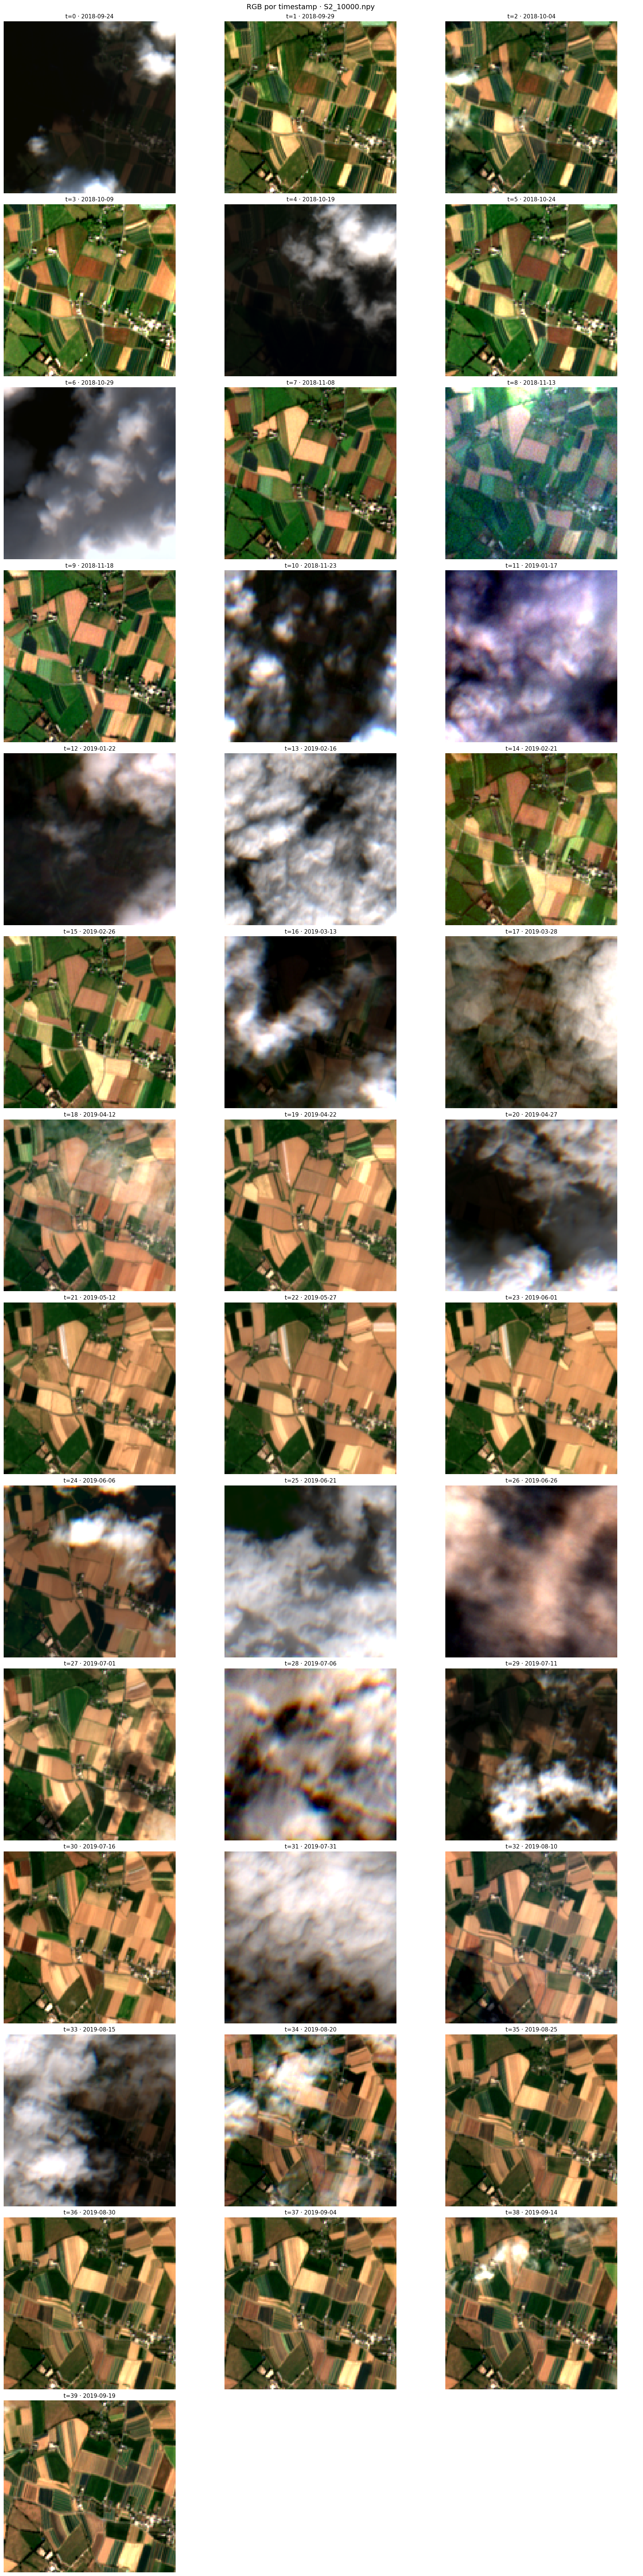

In [8]:

# --- Fechas: tomar SOLO la celda del parche y convertir a dict {t:int_fecha} ---
# patch_data debe tener una sola fila (el parche seleccionado)
dates_raw = patch_data['dates-S2'].iloc[0]          # dict como {'0': 20180924, '1': 20180929, ...}

# Pasar claves a int (t) y valores a Timestamp (YYYY-MM-DD)
dates = {int(k): pd.to_datetime(str(v), format="%Y%m%d") for k, v in dates_raw.items()}

# Ordenar por t y elegir cuántos mostrar
t_list = sorted(dates.keys())
n_show = min(40, len(t_list))                       # o 10 si quieres menos
t_list = t_list[:n_show]

# --- Función: RGB sencillo desde el cubo ---
# data: (T, C, H, W) | bands = índices de B4,B3,B2 para RGB natural (ORDER_10: 2,1,0)
def get_rgb_from_pastis(data, t, bands=(2,1,0), p_lo=2, p_hi=98):
    cube = data[t, list(bands)]                     # (3, H, W)
    vmin, vmax = np.nanpercentile(cube, [p_lo, p_hi])
    rgb = np.clip((cube - vmin) / (vmax - vmin + 1e-9), 0, 1)
    rgb = np.moveaxis(rgb, 0, -1)                  # (H, W, 3)
    return rgb

# --- Grilla de subplots (sin warnings de layout) ---
cols = 3
rows = max(1, math.ceil(n_show / cols))
fig, axs = plt.subplots(rows, cols, figsize=(18, rows * 5), constrained_layout=True)
axs = np.atleast_2d(axs).ravel()

# Por si algún t excede T (defensivo si hay llaves “huecas”)
T = data.shape[0]

for i, t in enumerate(t_list):
    if t >= T:
        continue
    ax = axs[i]
    rgb = get_rgb_from_pastis(data, t, bands=(2,1,0))
    ax.imshow(rgb)
    ax.set_title(f"t={t} · {dates[t].date().isoformat()}", fontsize=11)
    ax.axis("off")

# Ocultar ejes sobrantes
for j in range(i + 1, rows * cols):
    axs[j].axis("off")

fig.suptitle(f"RGB por timestamp · {chosen_img}", fontsize=14)
plt.show()



## PASTIS — Visualización por bandas (una fecha)

**Qué muestra esta figura**  
- Cada panel es una **banda espectral** de Sentinel-2 para **un mismo instante temporal** (índice `t`).
- Se muestra en **escala de grises**: tonos **claros** = valores más altos; tonos **oscuros** = valores más bajos.
- La cuadrícula recorre **todas las bandas** disponibles (`n_bands`) en el cubo (`data`).

**De dónde salen los datos**  
- `data` tiene forma **(T, C, H, W)** = *(tiempos, bandas, alto, ancho)*.  
- Aquí fijamos `t = 3` (puedes cambiarlo) y graficamos `data[t, band, :, :]` para `band = 0…C-1`.

**Para qué sirve**  
- Permite **comparar firmas espaciales** entre bandas:  
  - Bandas del visible (B2/B3/B4) resaltan diferencias en color aparente.  
  - Bandas del **NIR** y **SWIR** realzan **vegetación**, **humedad** del suelo y **presencia de agua**.  
- Ayuda a **detectar artefactos** (nubes, saturación, líneas, gaps) específicos de alguna banda.

- **Patrones coherentes** entre varias bandas sugieren cambios físicos reales.  
- Si un patrón aparece **solo** en una banda, puede ser ruido, nubes o diferencias de respuesta espectral.  
- **Más brillo** en NIR suele indicar **vegetación vigorosa**; **SWIR** elevado puede asociarse a **sequedad** o materiales con distinta reflectancia.

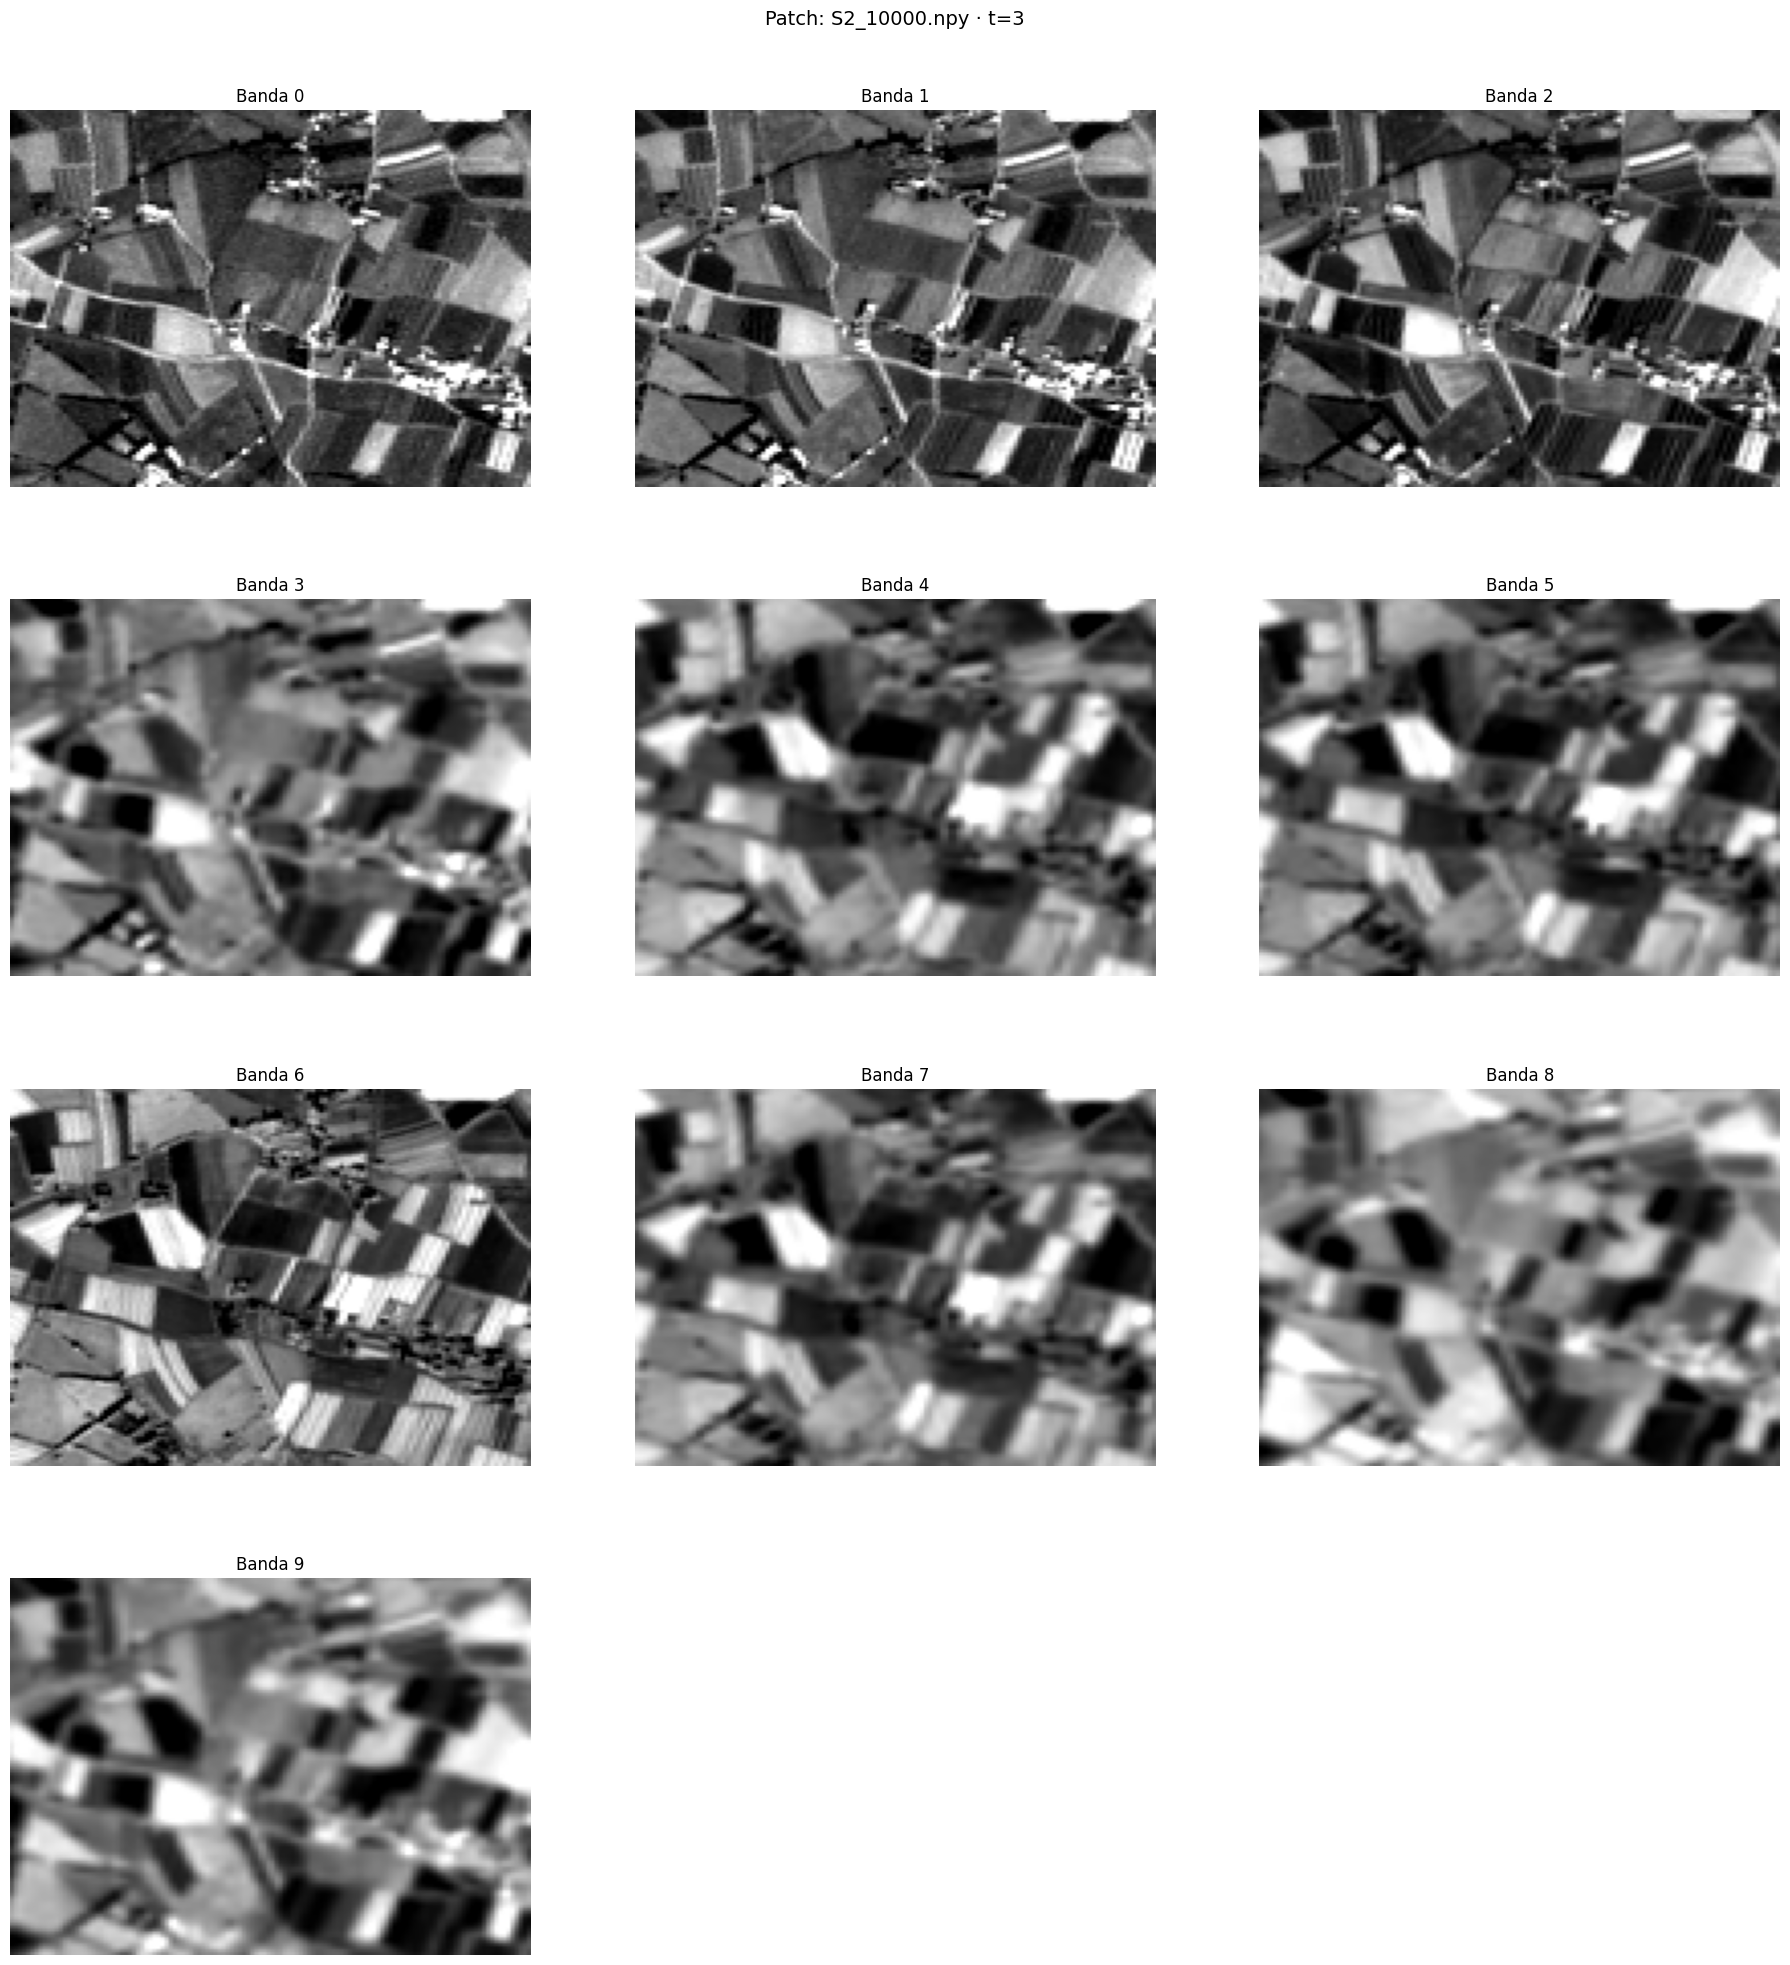

In [9]:
# data: arreglo 4D con forma (T, C, H, W)
# t: índice temporal a visualizar
# cols: columnas de la grilla
# p_lo, p_hi: percentiles para normalizar contraste por banda
# band_names: lista opcional con nombres de bandas (len == C)

def show_bands_grid(data, t=3, cols=3, p_lo=2, p_hi=98, band_names=None):
    T, C, H, W = data.shape
    rows = math.ceil(C / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axs = np.atleast_2d(axs).ravel()

    for band in range(C):
        ax = axs[band]
        img = data[t, band].astype(float)

        # Normalización robusta por percentiles (mejor contraste)
        lo, hi = np.nanpercentile(img, [p_lo, p_hi])
        img = (img - lo) / (hi - lo + 1e-9)
        img = np.clip(img, 0, 1)

        ax.imshow(img, cmap='gray', aspect='auto')
        title = band_names[band] if band_names and band < len(band_names) else f'Banda {band}'
        ax.set_title(title, fontsize=12)
        ax.axis('off')

    # Ocultar subplots vacíos
    for i in range(C, rows * cols):
        axs[i].axis('off')

    fig.suptitle(f'Patch: {chosen_img} · t={t}', fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.2)
    plt.show()

# --- Ejemplo de uso (ajusta t y, si los tienes, los nombres de bandas) ---
# band_names = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]  # si aplica
show_bands_grid(data, t=3, cols=3, p_lo=2, p_hi=98, band_names=None)


Visualización de un parche con anotaciones y heatmap

**Qué se muestra en la figura**  
1. **Imagen Sentinel-2 (RGB natural)**  
   - Una composición en color natural del parche para una fecha específica (`t_show`).  
   - Permite reconocer visualmente áreas verdes (vegetación activa), zonas marrones (suelo desnudo o rastrojo) y regiones claras (posibles nubes).

2. **Instancias (parcelas agrícolas)**  
   - Cada color representa una **parcela distinta** dentro del parche.  
   - Las parcelas están delineadas sobre una base en escala de grises (imagen satelital).  
   - Esto ayuda a conectar la geometría agrícola con la información espectral: vemos cómo cada parcela está segmentada y diferenciada de sus vecinas.

3. **Heatmap sobre la imagen base**  
   - Un mapa de calor superpuesto que destaca ciertas áreas según la información provista en `HEATMAP`.  
   - Puede interpretarse como **intensidad de una característica espacial** (ej. relevancia de píxeles en un modelo, nivel de confianza, probabilidad de clase).  
   - El contraste con la imagen satelital en gris permite ubicar las zonas más "calientes" dentro del contexto agrícola.


S2 (T,C,H,W): (43, 10, 128, 128) | instances: (128, 128) | zones: (128, 128) | heatmap: (128, 128)


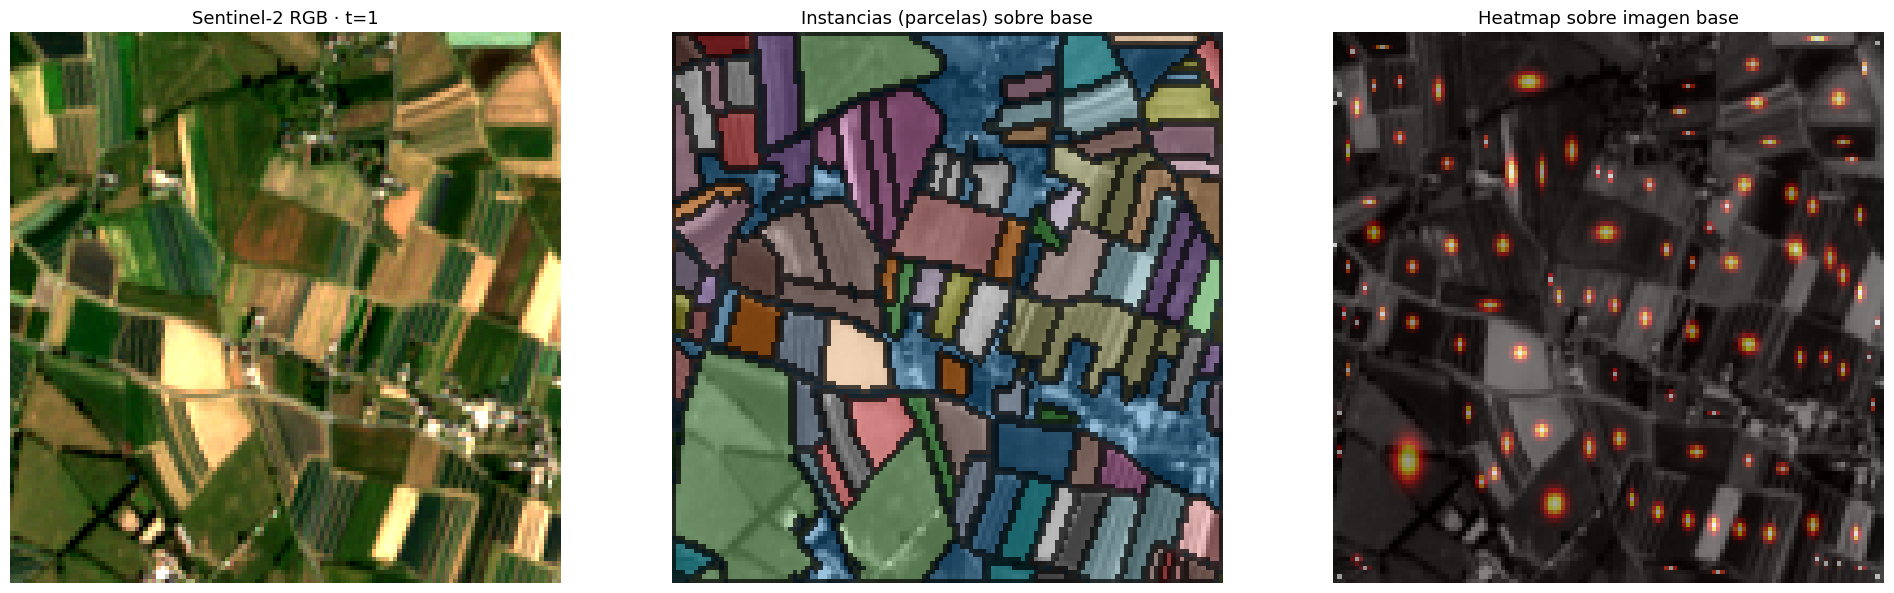

In [10]:
path = '../PASTIS/PASTIS/'

# --- Cargar arrays del parche seleccionado ---
image_s2  = np.load(f'{path}DATA_S2/S2_{id_patch}.npy')             # (T, C, H, W)
instances = np.load(f'{path}INSTANCE_ANNOTATIONS/INSTANCES_{id_patch}.npy')  # (H, W)
zones     = np.load(f'{path}INSTANCE_ANNOTATIONS/ZONES_{id_patch}.npy')      # (H, W)
parcel_ids= np.load(f'{path}ANNOTATIONS/ParcelIDs_{id_patch}.npy')           # (H, W)
heatmap   = np.load(f'{path}INSTANCE_ANNOTATIONS/HEATMAP_{id_patch}.npy')    # (H, W)
target    = np.load(f'{path}ANNOTATIONS/TARGET_{id_patch}.npy')              # (H, W)

# --- Información básica de formas (útil para alinear mentalmente los datos) ---
print(f"S2 (T,C,H,W): {image_s2.shape} | instances: {instances.shape} | zones: {zones.shape} | heatmap: {heatmap.shape}")

# --- Parámetros de visualización ---
t_show = 1                       # índice temporal a mostrar (ajústalo)
bands_rgb = (2, 1, 0)            # índices de bandas para R,G,B (ajústalo a tu orden real)
p_lo, p_hi = 2, 98               # percentiles para normalización de contraste

# --- Helpers simples para visualización ---
def to_rgb(s2, t, bands=(2,1,0), p=(2,98)):
    """Compone un RGB (H,W,3) desde image_s2[t], normalizando por percentiles para buen contraste."""
    rgb = s2[t, list(bands)]              # (3, H, W)
    lo, hi = np.nanpercentile(rgb, p)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-9), 0, 1)
    rgb = np.moveaxis(rgb, 0, -1)         # (H, W, 3)
    return rgb

def to_gray_from_rgb(rgb):
    """Gris simple desde RGB normalizado (promedio de canales)."""
    return rgb.mean(axis=2)

def parcel_boundaries(pid):
    """Mapa booleano de bordes de parcela a partir de parcel_ids (contornos por diferencias vecinas)."""
    up    = pid != np.roll(pid,  1, axis=0)
    down  = pid != np.roll(pid, -1, axis=0)
    left  = pid != np.roll(pid,  1, axis=1)
    right = pid != np.roll(pid, -1, axis=1)
    edges = up | down | left | right
    edges[0,:]  = edges[-1,:] = edges[:,0] = edges[:,-1] = True  # bordes del patch
    return edges

# --- Preparar bases de visualización ---
rgb  = to_rgb(image_s2, t_show, bands=bands_rgb, p=(p_lo, p_hi))   # (H, W, 3)
gray = to_gray_from_rgb(rgb)                                       # (H, W)
edges = parcel_boundaries(parcel_ids)                              # (H, W) bool

# --- Figura: RGB, Instancias, Heatmap ---
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1) RGB Sentinel-2
axs[0].imshow(rgb)
axs[0].set_title(f'Sentinel-2 RGB · t={t_show}', fontsize=13)
axs[0].axis('off')

# 2) Instancias sobre base gris (para ver forma de cada objeto)
axs[1].imshow(gray, cmap='gray', alpha=1.0)
axs[1].imshow(instances, cmap='tab20', alpha=0.45)
# contornos de parcela para dar contexto espacial
axs[1].imshow(np.where(edges, 1, np.nan), cmap='gray', alpha=0.7)  # línea gris fina
axs[1].set_title('Instancias (parcelas) sobre base', fontsize=13)
axs[1].axis('off')

# 3) Heatmap sobre base gris
axs[2].imshow(gray, cmap='gray', alpha=1.0)
axs[2].imshow(heatmap, cmap='hot', alpha=0.5)
axs[2].set_title('Heatmap sobre imagen base', fontsize=13)
axs[2].axis('off')

plt.tight_layout()
plt.show()


### Segmentación + instancias (parcelas)

**Qué muestra la figura**
- Fondo: **mapa semántico** por pixel (clase de cultivo) con una paleta categórica (0–19).
- Encima: **contornos** de cada **instancia** (parcela individual).
- Etiquetas: para las **parcelas más grandes**, se anota el **nombre de la clase** y el **ID de instancia** en su centroide.

**De dónde salen los datos**
- `target[0]` → `semantic`: **clase** por pixel (0–19) para segmentación semántica.
- `target[1]` → `instances`: **ID** de la **parcela** por pixel (0 = fondo / sin parcela).

**Cómo leer la figura**
- La **barra de color** (colorbar) lista solo las **clases presentes** en este parche.
- Los **contornos** ayudan a ver forma y límites de cada parcela; la etiqueta muestra la clase dominante de esa parcela.
- Etiquetamos solo las **parcelas de mayor área** (p. ej., top-30) para mantener legibilidad.


Clases presentes (semantic): [ 0  1  2  3  4  6 12 13 19]


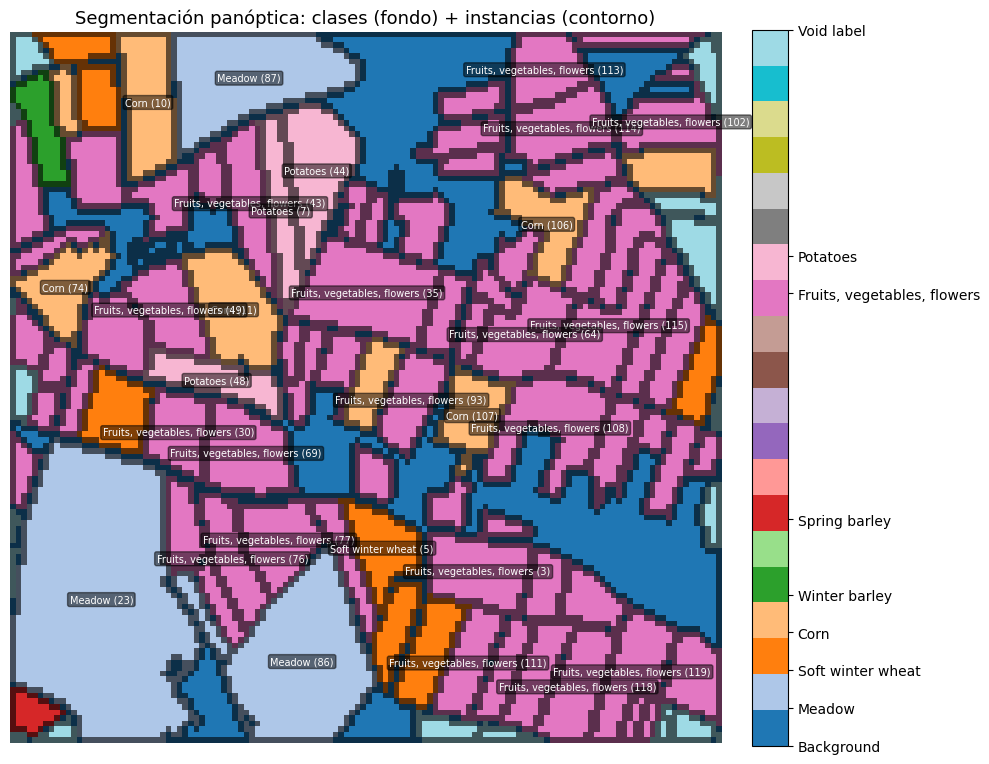

In [11]:
# --- Capas del target (panóptica) ---
semantic = target[0]   # (H, W) clases por pixel (0–19)
instances = target[1]  # (H, W) id de instancia por pixel (0 = sin instancia)

print("Clases presentes (semantic):", np.unique(semantic))

# --- Mapeo de clases -> nombre (PASTIS) ---
class_mapping = {
    0: "Background",
    1: "Meadow",
    2: "Soft winter wheat",
    3: "Corn",
    4: "Winter barley",
    5: "Winter rapeseed",
    6: "Spring barley",
    7: "Sunflower",
    8: "Grapevine",
    9: "Beet",
    10: "Winter triticale",
    11: "Winter durum wheat",
    12: "Fruits, vegetables, flowers",
    13: "Potatoes",
    14: "Leguminous fodder",
    15: "Soybeans",
    16: "Orchard",
    17: "Mixed cereal",
    18: "Sorghum",
    19: "Void label"
}

# --- Parámetros de visualización ---
max_labels = 30  # etiqueta solo las N parcelas más grandes para evitar ruido visual

# --- Funciones auxiliares ---
def instance_edges(inst_map):
    """Contornos de instancias por diferencia con vecinos (True en bordes)."""
    up    = inst_map != np.roll(inst_map,  1, axis=0)
    down  = inst_map != np.roll(inst_map, -1, axis=0)
    left  = inst_map != np.roll(inst_map,  1, axis=1)
    right = inst_map != np.roll(inst_map, -1, axis=1)
    edges = up | down | left | right
    edges[0,:] = edges[-1,:] = edges[:,0] = edges[:,-1] = True
    return edges

def top_instances_by_area(inst_map, k=30):
    """Devuelve ids de las k instancias con mayor área (excluye 0)."""
    ids, counts = np.unique(inst_map, return_counts=True)
    mask = ids != 0
    ids, counts = ids[mask], counts[mask]
    order = np.argsort(counts)[::-1]
    return ids[order][:k]

def instance_centroid(inst_map, inst_id):
    """Centroide (y,x) de una instancia vía promedio de coordenadas."""
    ys, xs = np.where(inst_map == inst_id)
    return float(ys.mean()), float(xs.mean())

def instance_majority_class(semantic_map, inst_map, inst_id):
    """Clase dominante (moda) dentro de la instancia."""
    ys, xs = np.where(inst_map == inst_id)
    classes = semantic_map[ys, xs].astype(int)
    counts = np.bincount(classes, minlength=20)
    return int(counts.argmax())

# --- Preparar paleta categórica y ticks de colorbar (solo clases presentes) ---
present_classes = np.unique(semantic)
cmap = plt.get_cmap('tab20', 20)  # paleta discreta de 20 colores
vmin, vmax = 0, 19

# --- Figura ---
fig, ax = plt.subplots(figsize=(10, 10))

# Fondo: mapa semántico (categórico)
im = ax.imshow(semantic, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_title("Segmentación panóptica: clases (fondo) + instancias (contorno)", fontsize=13)
ax.axis('off')

# Colorbar con etiquetas de las clases presentes
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=present_classes)
cbar.ax.set_yticklabels([class_mapping.get(int(c), str(int(c))) for c in present_classes])

# Contornos de instancias (en gris) para dar contexto de límites
edges = instance_edges(instances)
ax.imshow(np.where(edges, 1, np.nan), cmap='gray', alpha=0.6)

# Etiquetas: solo las instancias de mayor área (centroide + clase dominante)
label_ids = top_instances_by_area(instances, k=max_labels)
for inst_id in label_ids:
    cy, cx = instance_centroid(instances, inst_id)
    maj_cls = instance_majority_class(semantic, instances, inst_id)
    cls_name = class_mapping.get(maj_cls, "Unknown")
    ax.text(
        cx, cy,
        f"{cls_name} ({inst_id})",
        color='white', fontsize=7, ha='center', va='center',
        bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2')
    )

plt.tight_layout()
plt.show()


## PASTIS — Distribución de cultivos

**Objetivo**  
Contar cuántas **parcelas** pertenecen a cada **clase de cultivo** en todo el dataset PASTIS y visualizarlo en una **gráfica de barras**.

**Datos usados**  
- Archivos `TARGET_*.npy` en `ANNOTATIONS/`.
- Cada `target` contiene:
  - `target[0]` → **semantic** (H×W): clase por píxel (IDs 0–19).
  - `target[1]` → **instances** (H×W): ID de **parcela** por píxel (0 = sin parcela).

**Cómo se calcula**  
1. Para cada archivo `TARGET_*.npy`, se leen `semantic` e `instances`.  
2. Se recorre cada **parcela** (`instance_id ≠ 0`).  
3. Para esa parcela, se toma la **clase dominante** = **moda** de los píxeles de `semantic` dentro de sus límites.  
4. Se incrementa el conteo de esa clase.  
5. Al final, se grafica el **número total de parcelas por clase** (0–19) y su **porcentaje** relativo.

**Interpretación**  
- La altura de cada barra = **# de parcelas** etiquetadas con esa **clase dominante**.  
- El porcentaje sobre la barra = proporción respecto al total de parcelas del dataset.  
- Las clases **0 (Background)** y **19 (Void label)** pueden aparecer si alguna parcela fue dominada por esas etiquetas; se incluyen para mostrar **todas** las categorías.

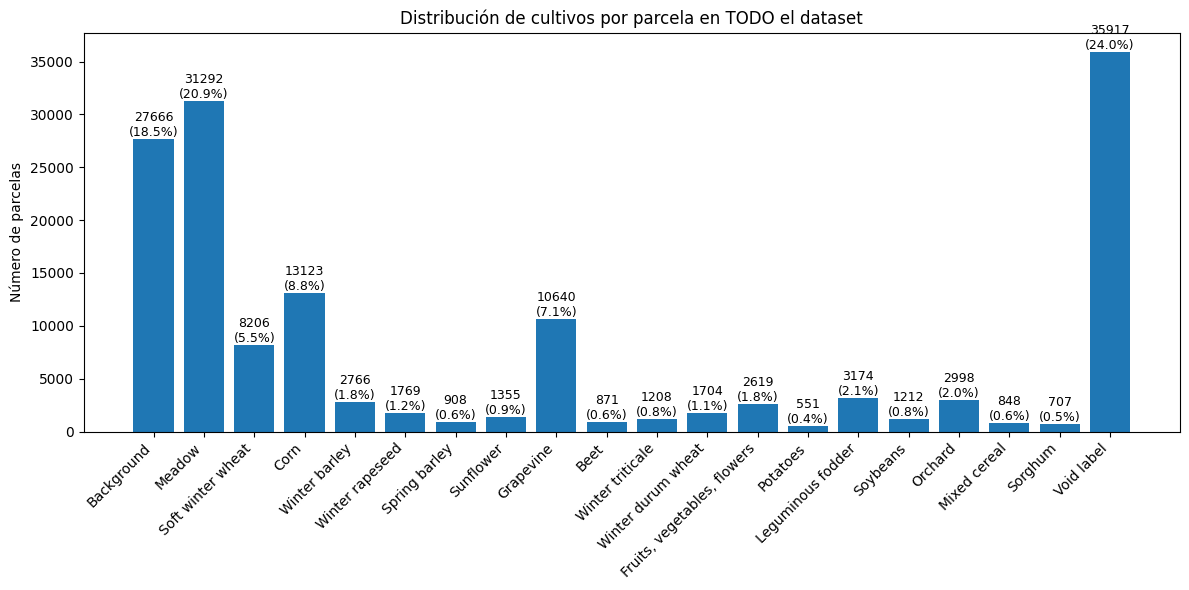

In [9]:
# --- Configuración de rutas ---
path = '../PASTIS/PASTIS/'
target_files = sorted(glob(f'{path}ANNOTATIONS/TARGET_*.npy'))

# --- Acumulador de parcelas por clase (0–19) ---
counts_per_class = np.zeros(20, dtype=int)

# --- Recorre TODO el dataset (cada TARGET_*.npy) ---
for fp in target_files:
    target = np.load(fp)           # target[0]=semantic (H,W), target[1]=instances (H,W)
    semantic  = target[0].astype(int)
    inst_map  = target[1].astype(int)

    inst_ids = np.unique(inst_map)
    inst_ids = inst_ids[inst_ids != 0]  # 0 = sin instancia

    # Clase dominante (moda) por parcela
    for iid in inst_ids:
        ys, xs = np.where(inst_map == iid)
        cls_vals = semantic[ys, xs]
        maj = int(np.bincount(cls_vals, minlength=20).argmax())
        counts_per_class[maj] += 1

# --- Preparar etiquetas y porcentajes (todas las categorías 0–19) ---
labels = [class_mapping[i] for i in range(20)]
values = counts_per_class
total_parcels = values.sum()
perc = np.where(total_parcels > 0, (values / total_parcels * 100), 0)

# --- Gráfica de barras (todas las categorías en orden) ---
plt.figure(figsize=(12, 6))
bars = plt.bar(range(20), values)
plt.xticks(range(20), labels, rotation=45, ha='right')
plt.ylabel("Número de parcelas")
plt.title("Distribución de cultivos por parcela en TODO el dataset")

# Anotar conteo y porcentaje encima de cada barra
for i, (v, p) in enumerate(zip(values, perc)):
    plt.text(i, v, f"{v}\n({p:.1f}%)", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


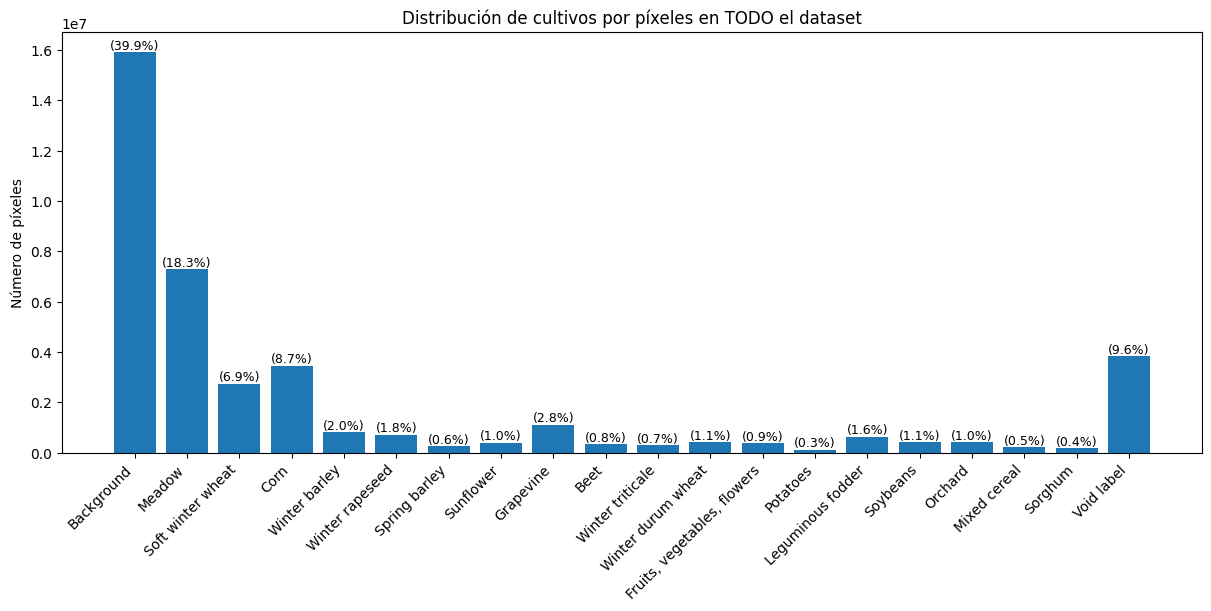

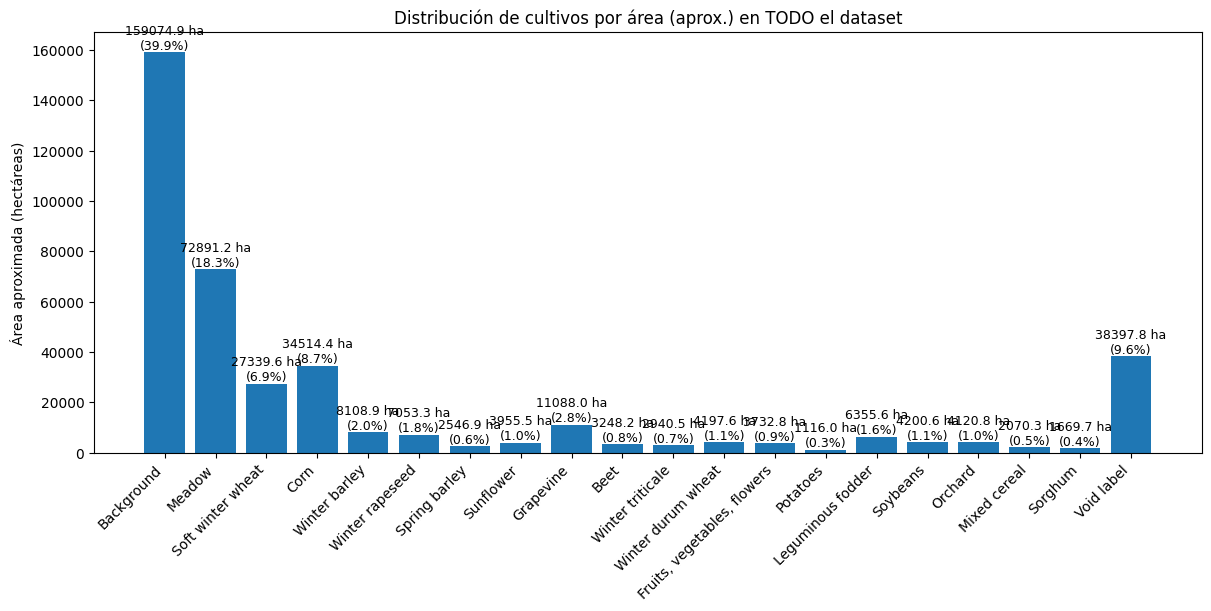

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# ==========================
# Configuración de rutas
# ==========================
path = '../PASTIS/PASTIS/'
target_files = sorted(glob(f'{path}ANNOTATIONS/TARGET_*.npy'))

# ==========================
# Mapeo de clases (0..19)
# ==========================
class_mapping = {
  0: "Background",
  1: "Meadow",
  2: "Soft winter wheat",
  3: "Corn",
  4: "Winter barley",
  5: "Winter rapeseed",
  6: "Spring barley",
  7: "Sunflower",
  8: "Grapevine",
  9: "Beet",
  10: "Winter triticale",
  11: "Winter durum wheat",
  12: "Fruits, vegetables, flowers",
  13: "Potatoes",
  14: "Leguminous fodder",
  15: "Soybeans",
  16: "Orchard",
  17: "Mixed cereal",
  18: "Sorghum",
  19: "Void label"
}

# ==========================
# Conteo por PÍXELES (no por parcela)
# ==========================
counts_pixels = np.zeros(20, dtype=np.int64)

for fp in target_files:
    # target[0] = semantic (H,W) con IDs de clase 0..19
    semantic = np.load(fp)[0].astype(int)
    # bincount sobre todos los píxeles del parche
    counts_pixels += np.bincount(semantic.ravel(), minlength=20)

# ==========================
# Preparar datos para la gráfica
# ==========================
labels = [class_mapping[i] for i in range(20)]
values = counts_pixels
total_pixels = values.sum()
perc = np.where(total_pixels > 0, (values / total_pixels * 100), 0)

# ==========================
# Gráfica de barras (por píxeles)
# ==========================
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
bars = ax.bar(range(20), values)
ax.set_xticks(range(20))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel("Número de píxeles")
ax.set_title("Distribución de cultivos por píxeles en TODO el dataset")

# Anotar conteo y porcentaje encima de cada barra
for i, (v, p) in enumerate(zip(values, perc)):
    ax.text(i, v, f"({p:.1f}%)", ha='center', va='bottom', fontsize=9)

plt.show()

# ==========================
# (Opcional) Conversión a área aproximada
# Sentinel-2 (10 m) → 1 píxel ≈ 100 m² = 0.01 ha
# ==========================
hectareas = values * 0.01
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
bars = ax.bar(range(20), hectareas)
ax.set_xticks(range(20))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel("Área aproximada (hectáreas)")
ax.set_title("Distribución de cultivos por área (aprox.) en TODO el dataset")
for i, (ha, p) in enumerate(zip(hectareas, perc)):
    ax.text(i, ha, f"{ha:.1f} ha\n({p:.1f}%)", ha='center', va='bottom', fontsize=9)
plt.show()


## Evolución temporal de índices espectrales

**Objetivo**  
Estimar cómo evolucionan en el tiempo tres índices espectrales (NDVI, NDWI, NDBI) promediados sobre **todas las parcelas** y **todas las escenas** del dataset PASTIS.

**Datos**  
- `DATA_S2/S2_{ID}.npy`: cubo Sentinel-2 por parche con forma **(T, C, H, W)**  
  - **T** = número de fechas (varía entre parches)  
  - **C** = bandas multiespectrales (p. ej., 10, 12 o 13 bandas)  
  - **H, W** = tamaño espacial del parche  
- Se asumen bandas Sentinel-2 estándar (por nombre): **B2 (Blue), B3 (Green), B4 (Red), B8 (NIR), B11 (SWIR)**.  
  El código mapea sus **índices** según **C** (10/12/13) para extraerlas correctamente.

**Índices calculados (por píxel, luego promediados espacialmente)**  
- **NDVI (vegetación):** \[(NIR − RED) / (NIR + RED)\] → vigor vegetativo.  
- **NDWI (agua):** \[(GREEN − NIR) / (GREEN + NIR)\] → contenido de agua superficial/vegetal.  
- **NDBI (urbano):** \[(SWIR − NIR) / (SWIR + NIR)\] → superficies construidas/urbanas.

**Método (resumen de pasos de datos)**  
1. Para **cada parche** `S2_*.npy` y **cada fecha t**, se calculan NDVI, NDWI y NDBI **promediando en H×W** (índice medio por parche y fecha).  
2. Cada parche puede tener **T distinto**; por eso las series se **alinean** con *padding* de **NaN** hasta `T_max`.  
3. Se obtiene la **media por tiempo** aplicando `nanmean` (ignora NaN), resultando en una curva temporal global por índice.  
4. Se grafican las tres curvas (eje X = **t**; eje Y = **valor medio del índice**).

**Cómo leer las curvas**  
- **NDVI**: estacionalidad y picos sugieren periodos de crecimiento/cosecha.  
- **NDWI**: aumentos pueden asociarse a humedad/agua (lluvia, inundación, riego).  
- **NDBI**: valores altos indican mayor presencia de superficies construidas; suele ser estable en áreas agrícolas.


Parches por t (primeros 20): [2468 2468 2468 2468 2468 2468 2468 2468 2468 2468 2468 2468 2468 2468
 2468 2468 2468 2468 2468 2468]


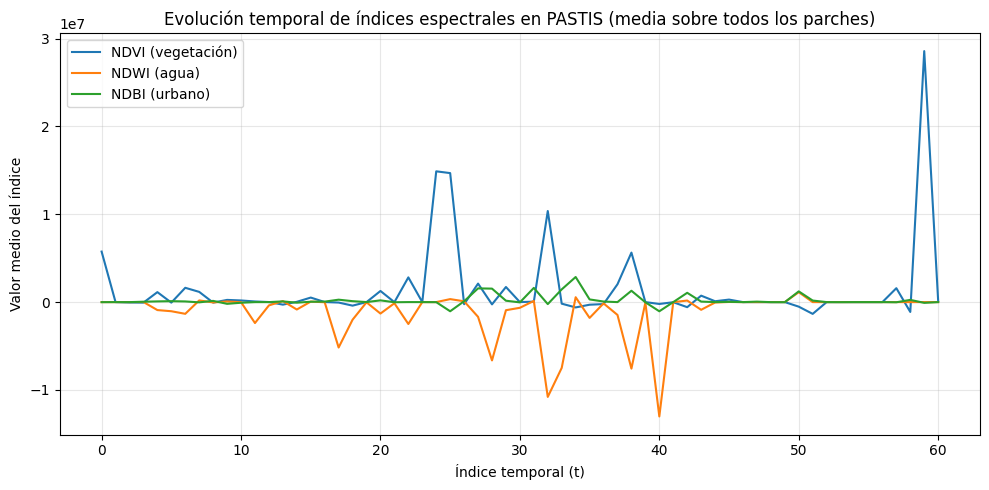

In [11]:

# --- Rutas ---
root = '../PASTIS/PASTIS/'
s2_files = sorted(glob(f"{root}DATA_S2/S2_*.npy"))

# --- Utilidades centradas en datos ---

# Mapeos típicos de bandas S2 (índices 0-basados) según número de canales C.
# Usamos nombres estándar Sentinel-2:
# B2=Blue, B3=Green, B4=Red, B8=NIR, B11=SWIR
ORDER_10 = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]
ORDER_12 = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12"]
ORDER_13 = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B10","B11","B12"]

def get_band_index_map(C):
    """Devuelve índices de bandas clave {'B2','B3','B4','B8','B11'} según C (10/12/13)."""
    if C == 10:
        order = ORDER_10
    elif C == 12:
        order = ORDER_12
    elif C == 13:
        order = ORDER_13
    else:
        # fallback simple: asumir el orden de 10 bandas más usado
        order = ORDER_10
    idx = {b:i for i,b in enumerate(order)}
    needed = ("B2","B3","B4","B8","B11")
    return {k: idx[k] for k in needed if k in idx}

def safe_norm(a, b):
    """(a-b)/(a+b) con estabilización numérica para evitar divisiones por 0."""
    return (a - b) / (a + b + 1e-9)

def pad_stack(list_of_lists, fill_value=np.nan):
    """Apila listas de longitudes variables en una matriz 2D con padding NaN."""
    max_len = max(len(x) for x in list_of_lists)
    out = np.full((len(list_of_lists), max_len), fill_value, dtype=float)
    for i, row in enumerate(list_of_lists):
        out[i, :len(row)] = row
    return out

# --- Acumuladores: una serie (longitud T_i) por parche ---
all_ndvi, all_ndwi, all_ndbi = [], [], []

# --- Recorrido del dataset ---
for fp in s2_files:
    arr = np.load(fp)                 # (T, C, H, W)
    T, C, H, W = arr.shape
    bidx = get_band_index_map(C)
    # Si falta alguna banda clave, saltamos este parche (evita fuera de rango)
    if not all(k in bidx for k in ("B2","B3","B4","B8","B11")):
        continue

    B2, B3, B4, B8, B11 = bidx["B2"], bidx["B3"], bidx["B4"], bidx["B8"], bidx["B11"]

    ndvi_t, ndwi_t, ndbi_t = [], [], []
    for t in range(T):
        # Bandas por tiempo t
        blue  = arr[t, B2]
        green = arr[t, B3]
        red   = arr[t, B4]
        nir   = arr[t, B8]
        swir  = arr[t, B11]

        # Índices por pixel -> promedio espacial (H,W) para esta fecha
        ndvi_t.append(safe_norm(nir, red).mean())
        ndwi_t.append(safe_norm(green, nir).mean())
        ndbi_t.append(safe_norm(swir, nir).mean())

    all_ndvi.append(ndvi_t)
    all_ndwi.append(ndwi_t)
    all_ndbi.append(ndbi_t)

# --- Alineación temporal (NaN padding) y promedio por tiempo ---
ndvi_mat = pad_stack(all_ndvi)   # shape (N_patches, T_max)
ndwi_mat = pad_stack(all_ndwi)
ndbi_mat = pad_stack(all_ndbi)

mean_ndvi = np.nanmean(ndvi_mat, axis=0)
mean_ndwi = np.nanmean(ndwi_mat, axis=0)
mean_ndbi = np.nanmean(ndbi_mat, axis=0)

# (Opcional) cuántos parches aportan en cada t (útil para interpretar extremos)
n_contrib = np.sum(~np.isnan(ndvi_mat), axis=0)
print(f"Parches por t (primeros 20): {n_contrib[:20]}")

# --- Gráfica: evolución temporal promedio de índices ---
plt.figure(figsize=(10,5))
plt.plot(mean_ndvi, label="NDVI (vegetación)")
plt.plot(mean_ndwi, label="NDWI (agua)")
plt.plot(mean_ndbi, label="NDBI (urbano)")
plt.xlabel("Índice temporal (t)")
plt.ylabel("Valor medio del índice")
plt.title("Evolución temporal de índices espectrales en PASTIS (media sobre todos los parches)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## NDVI en serie temporal (parche PASTIS)

**Qué se ve**  
Mosaico de imágenes **NDVI** del mismo parche Sentinel-2 en distintos tiempos.  
Cada panel corresponde a una fecha (t), con **rojo = baja vegetación** y **verde = alta vegetación** (escala fija −1…1).

**Cómo leerlo en PASTIS**  
- El NDVI alto (verde intenso) sugiere **vegetación vigorosa**; valores bajos (amarillo/rojo) indican **suelo desnudo**, **cosecha reciente**, **agua** o **sombra**.  
- Comparando paneles se aprecian **patrones fenológicos** (sube y baja a lo largo de la campaña) y **eventos**: riego, sequía, nubes.  
- Esta vista rápida ayuda a elegir **fechas útiles** y detectar **outliers** antes de análisis cuantitativos por parcela o por clase de cultivo.


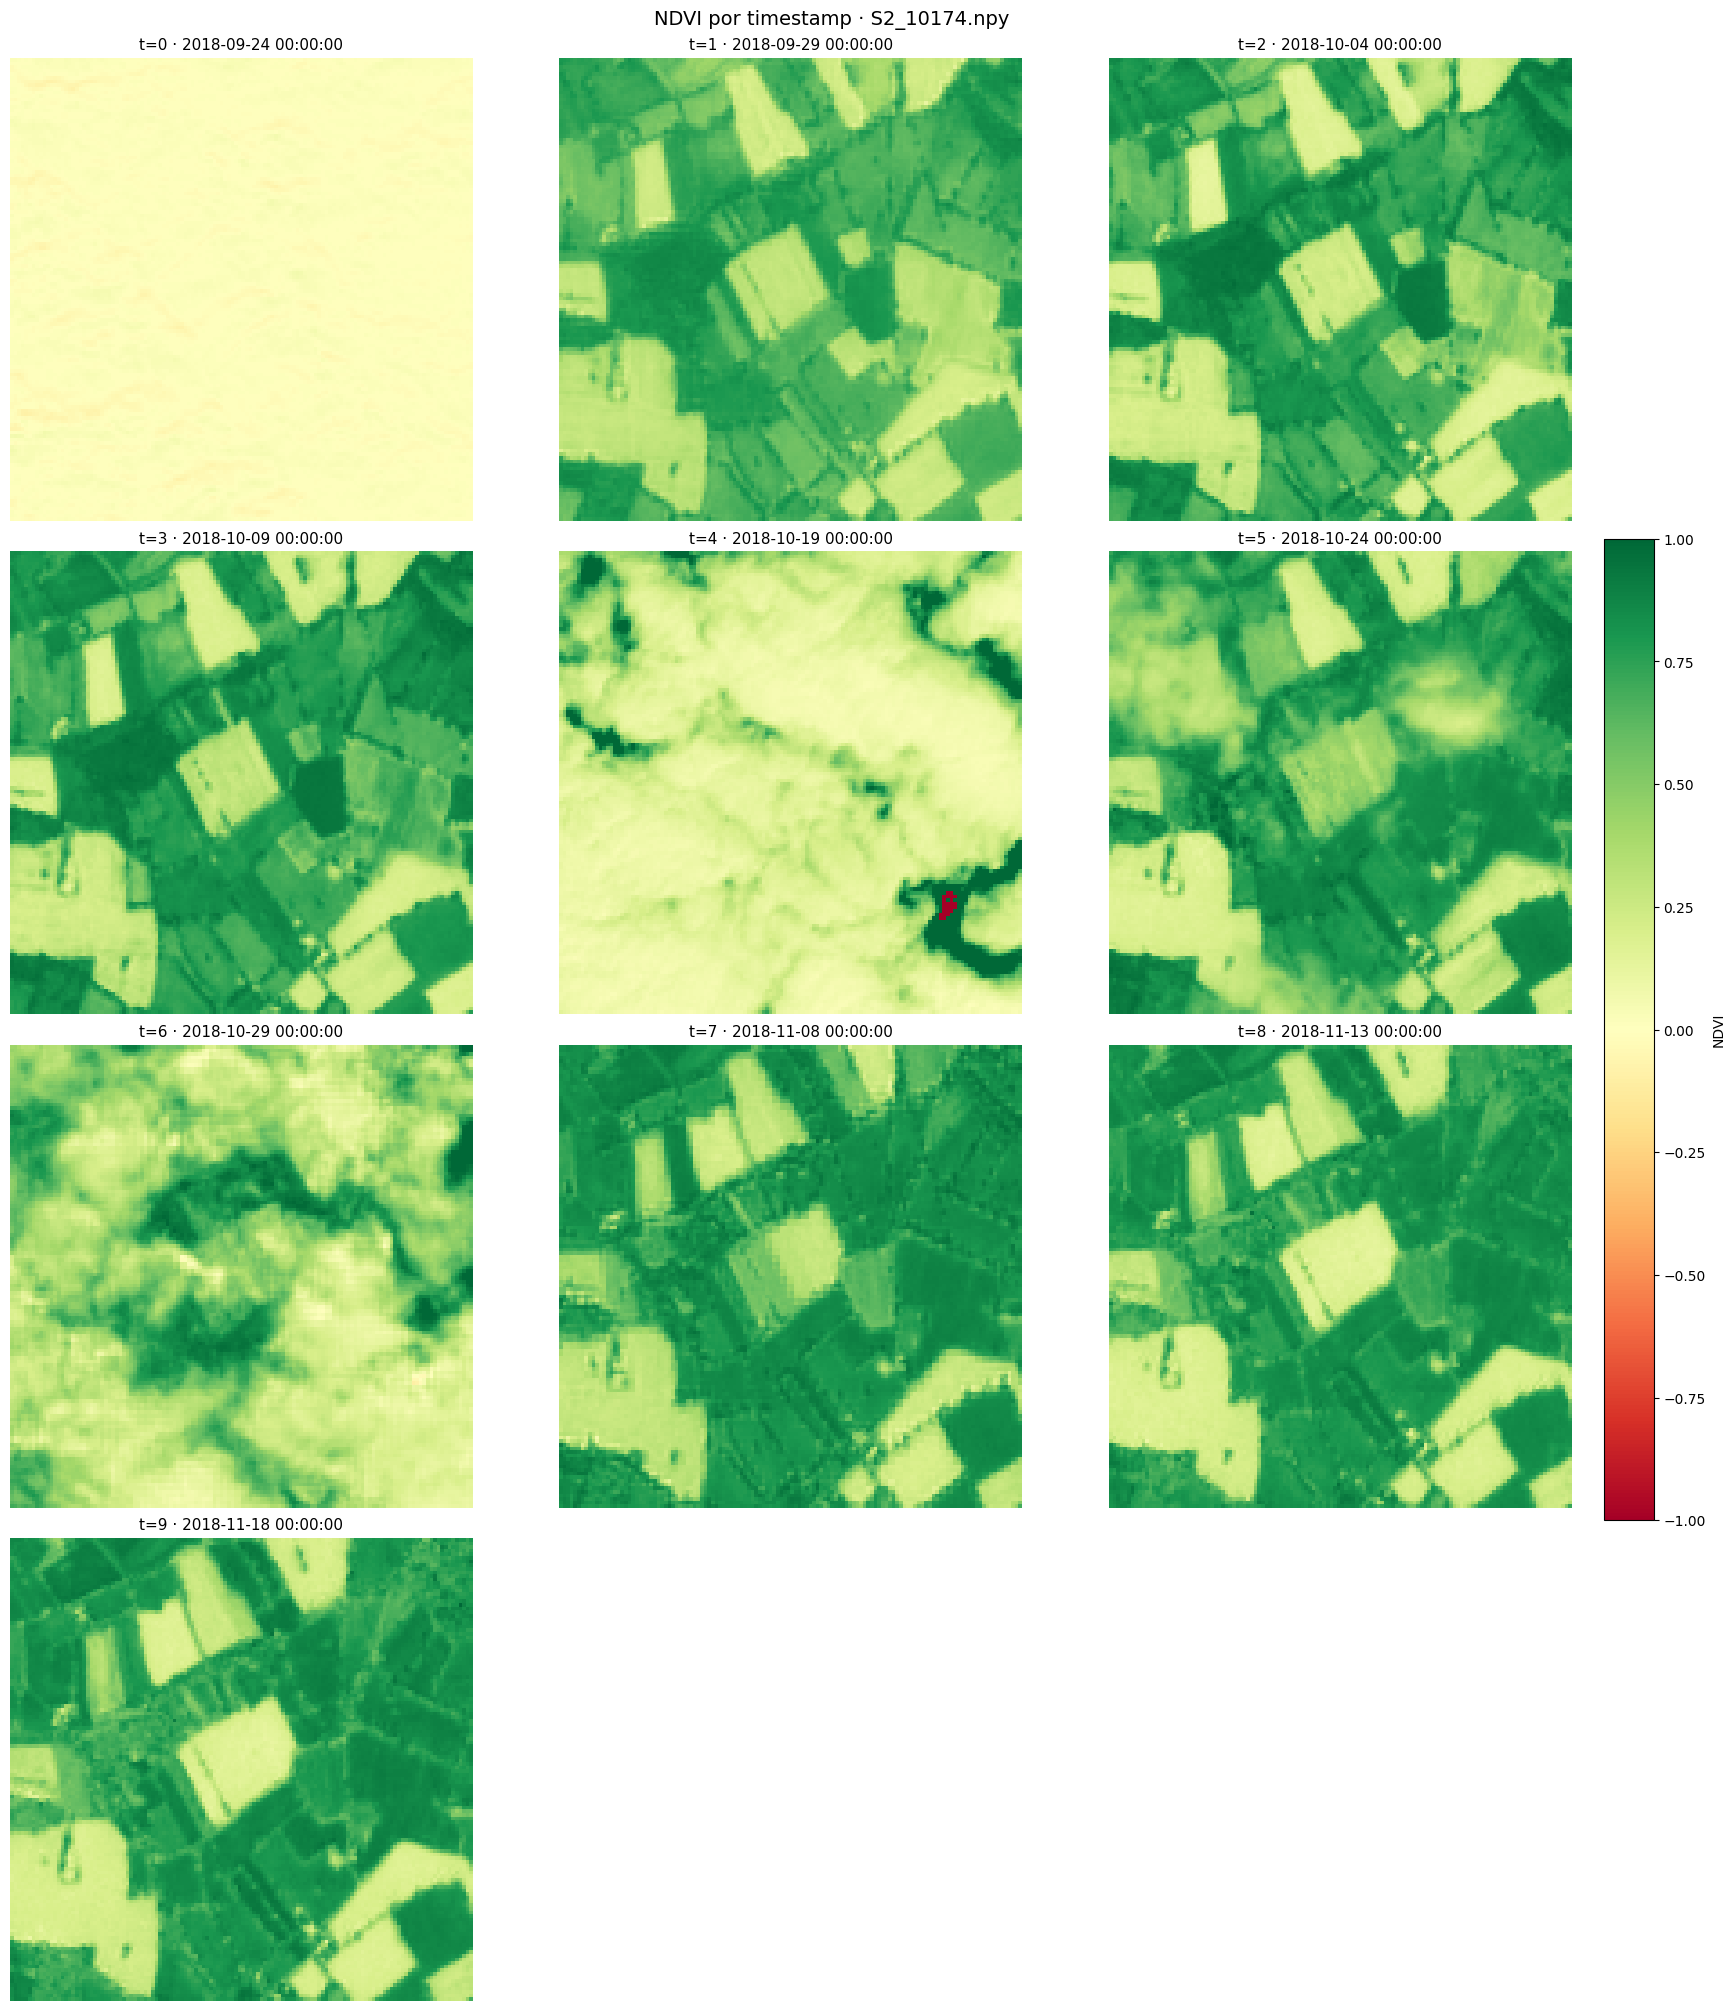

In [12]:

# --- Fechas: tomar SOLO la celda del parche y convertir a dict {t:int_fecha} ---
# patch_data debe tener una sola fila (el parche seleccionado)
dates_raw = patch_data['dates-S2'].iloc[0]          # dict como {'0': 20180924, '1': 20180929, ...}

# Pasar claves a int (t) y valores a Timestamp (YYYY-MM-DD)
dates = {int(k): pd.to_datetime(str(v), format="%Y%m%d") for k, v in dates_raw.items()}
# --- Fechas: convertir llaves a int y ordenar por t ---
t_list = sorted(dates.keys())
n_show = min(10, len(t_list)) 
t_list = t_list[:n_show]

# --- NDVI por timestamp ---
# data: (T, C, H, W) con ORDER_10 -> B4=2 (Rojo), B8=6 (NIR)
def get_ndvi_from_pastis(data, t, nir_idx=6, red_idx=2):
    nir = data[t, nir_idx].astype(float)
    red = data[t, red_idx].astype(float)
    return (nir - red) / (nir + red + 1e-9)  # [-1,1]

# --- Grilla de subplots (usar constrained_layout para evitar el warning) ---
cols = 3
rows = max(1, math.ceil(n_show / cols))
fig, axs = plt.subplots(rows, cols, figsize=(18, rows * 5), constrained_layout=True)
axs = np.atleast_2d(axs).ravel()

# Escala y paleta comunes
vmin, vmax = -1.0, 1.0
cmap = "RdYlGn"   # rojo (bajo) -> verde (alto)
last_im = None

for i, t in enumerate(t_list):
    ax = axs[i]
    ndvi = get_ndvi_from_pastis(data, t, nir_idx=6, red_idx=2)
    last_im = ax.imshow(ndvi, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"t={t} · {dates[t]}", fontsize=11)
    ax.axis("off")

# Ocultar ejes sobrantes
for j in range(i + 1, rows * cols):
    axs[j].axis("off")

# Colorbar compartido (compatible con constrained_layout)
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axs[:n_show], location='right', fraction=0.03, pad=0.02)
    cbar.set_label("NDVI", rotation=90)

fig.suptitle(f"NDVI por timestamp · {chosen_img}", fontsize=14)
plt.show()


## PASTIS — Evolución temporal de NDVI/NDWI/NDBI por tipo de cultivo (dataset completo)

**Qué se muestra**  
- Para cada **clase de cultivo** del dataset (p. ej., trigo de invierno, maíz, girasol), se grafica una **serie temporal** del índice (NDVI, NDWI o NDBI) promediado **entre parches** en cada instante `t`.  
- Cada línea = **un cultivo**; el eje X es el **índice temporal** (se puede mapear a fechas del metadata), y el eje Y es el **valor promedio del índice** (−1 a 1 aprox.).

**Cómo leerlo en PASTIS**  
- **NDVI** (vegetación): picos y valles reflejan la **fenología** (crecimiento, máximo verde, cosecha).  
  - Cultivos de **invierno** suelen subir antes (primavera); **verano** suben más tarde.  
- **NDWI** (agua/humedad): aumentos puntuales suelen asociarse a **lluvia**, **riego** o suelos húmedos.  
- **NDBI** (urbano/suelo expuesto): valores más altos indican menos vegetación; en áreas agrícolas suele ser bajo y estable.
- Permite comparar **calendarios de cultivo** y detectar **desfase** entre clases.  
- Ayuda a identificar **meses/fechas representativas** para entrenamiento o validación y a localizar **outliers** (fechas con nubes o problemas).


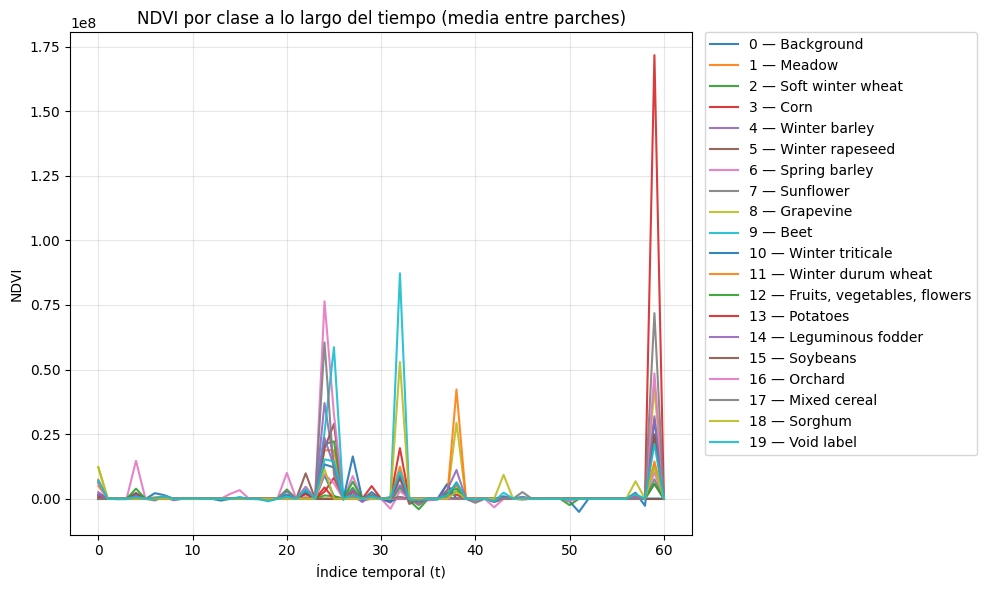

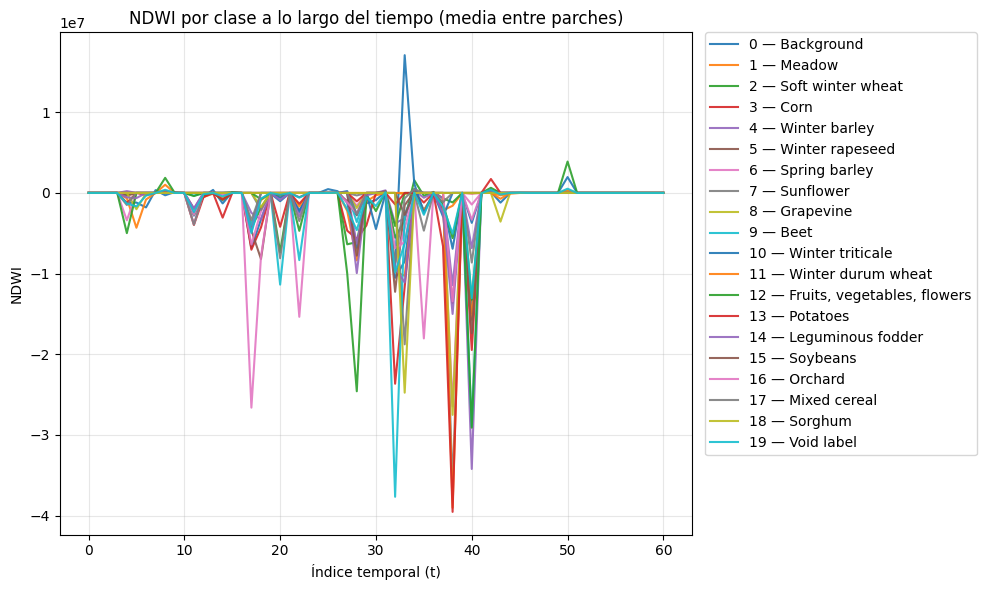

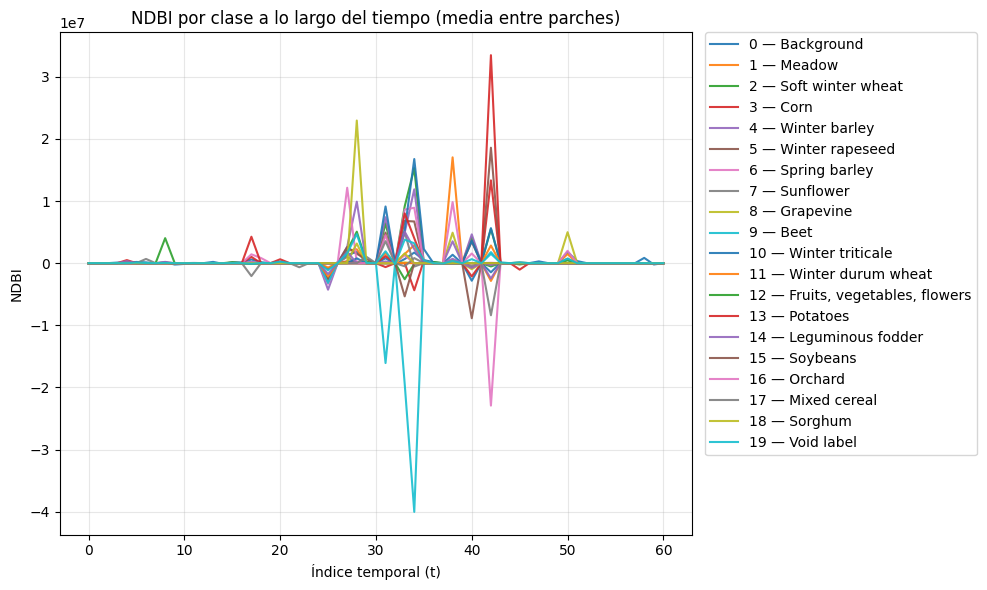

In [26]:
# ==========================
# Configuración de rutas
# ==========================
root = '../PASTIS/PASTIS/'
s2_paths     = sorted(glob(f"{root}DATA_S2/S2_*.npy"))
target_paths = sorted(glob(f"{root}ANNOTATIONS/TARGET_*.npy"))

# Emparejar por id de parche
def get_id(fp, pat):
    m = re.search(pat, fp)
    return m.group(1) if m else None

s2_by_id = { get_id(p, r"S2_(\d+)\.npy"): p for p in s2_paths }
tgt_by_id= { get_id(p, r"TARGET_(\d+)\.npy"): p for p in target_paths }
ids = sorted(set(s2_by_id.keys()) & set(tgt_by_id.keys()))

all_classes = list(range(20))  # 0..19

# ==========================
# Bandas (ORDER_10)
# ==========================
# [B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12] -> 0..9
B2, B3, B4, B8, B11 = 0, 1, 2, 6, 8

def safe_norm(a, b):
    return (a - b) / (a + b + 1e-9)

# ==========================
# Acumuladores: por clase -> suma y conteo por t
# (listas que se van extendiendo hasta el T máximo observado)
# ==========================
def make_accumulators():
    return {c: [] for c in all_classes}, {c: [] for c in all_classes}

sum_ndvi, cnt_ndvi = make_accumulators()
sum_ndwi, cnt_ndwi = make_accumulators()
sum_ndbi, cnt_ndbi = make_accumulators()

def ensure_len(arr, length):
    """Extiende una lista con ceros hasta 'length'."""
    if len(arr) < length:
        arr.extend([0.0] * (length - len(arr)))

def ensure_len_int(arr, length):
    """Extiende una lista con enteros (0) hasta 'length'."""
    if len(arr) < length:
        arr.extend([0] * (length - len(arr)))

# ==========================
# Recorrer todo el dataset
# ==========================
for pid in ids:
    s2 = np.load(s2_by_id[pid])                # (T,C,H,W)
    tgt = np.load(tgt_by_id[pid])
    semantic = tgt[0].astype(int)              # (H,W)
    T, C, H, W = s2.shape

    # Por cada tiempo t, calcular promedios por clase en este parche
    for t in range(T):
        nir   = s2[t, B8].astype(float)
        red   = s2[t, B4].astype(float)
        green = s2[t, B3].astype(float)
        swir  = s2[t, B11].astype(float)

        ndvi_img = safe_norm(nir, red)
        ndwi_img = safe_norm(green, nir)
        ndbi_img = safe_norm(swir, nir)

        # Clases presentes en este parche
        present = np.unique(semantic)

        # Para cada clase presente, media espacial en la clase (si hay píxeles)
        for c in present:
            mask = (semantic == c)
            if not mask.any():
                continue

            ndvi_mean = ndvi_img[mask].mean()
            ndwi_mean = ndwi_img[mask].mean()
            ndbi_mean = ndbi_img[mask].mean()

            # Extender acumuladores hasta índice t
            ensure_len(sum_ndvi[c], t+1); ensure_len_int(cnt_ndvi[c], t+1)
            ensure_len(sum_ndwi[c], t+1); ensure_len_int(cnt_ndwi[c], t+1)
            ensure_len(sum_ndbi[c], t+1); ensure_len_int(cnt_ndbi[c], t+1)

            # Sumar "media del parche" y contar 1 parche que aporta en ese t
            sum_ndvi[c][t] += ndvi_mean; cnt_ndvi[c][t] += 1
            sum_ndwi[c][t] += ndwi_mean; cnt_ndwi[c][t] += 1
            sum_ndbi[c][t] += ndbi_mean; cnt_ndbi[c][t] += 1

# ==========================
# Convertir a arrays y calcular medias por clase y t
# ==========================
def means_from_sum_cnt(sum_dict, cnt_dict):
    out = {}
    for c in all_classes:
        if len(sum_dict[c]) == 0:
            out[c] = np.array([])
            continue
        s = np.array(sum_dict[c], dtype=float)
        n = np.array(cnt_dict[c], dtype=float)
        m = np.where(n > 0, s / n, np.nan)  # NaN donde ninguna escena aportó
        out[c] = m
    return out

mean_ndvi = means_from_sum_cnt(sum_ndvi, cnt_ndvi)
mean_ndwi = means_from_sum_cnt(sum_ndwi, cnt_ndwi)
mean_ndbi = means_from_sum_cnt(sum_ndbi, cnt_ndbi)

# ==========================
# Graficar: una figura por índice, líneas por clase
# ==========================
def plot_index_per_class(mean_dict, title, ylabel):
    plt.figure(figsize=(10,6))
    for c in all_classes:
        m = mean_dict[c]
        if m.size == 0 or np.all(np.isnan(m)):
            continue
        label = f"{c} — {class_mapping.get(c, str(c))}"
        plt.plot(m, label=label, alpha=0.9)  # una línea por clase
    plt.xlabel("Índice temporal (t)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    # Leyenda fuera para que quepan todas las clases
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()

plot_index_per_class(mean_ndvi, "NDVI por clase a lo largo del tiempo (media entre parches)", "NDVI")
plot_index_per_class(mean_ndwi, "NDWI por clase a lo largo del tiempo (media entre parches)", "NDWI")
plot_index_per_class(mean_ndbi, "NDBI por clase a lo largo del tiempo (media entre parches)", "NDBI")


## NDVI/NDWI/NDBI por **tipo de cultivo** en un patch (10174)

**Qué ves**
- Tres gráficas (NDVI, NDWI, NDBI) donde **cada línea** corresponde a un **tipo de cultivo** presente en el patch.
- El eje **X** es el **índice temporal** `t` (puede mapearse a fechas reales con `metadata`).
- El eje **Y** es el **valor medio del índice** en esa **clase** dentro del patch (promedio de píxeles de esa clase para cada `t`).
- Se excluyen `0=Background` y `19=Void`: solo ves cultivos reales.

**Cómo leerlo en el contexto de PASTIS**
- **NDVI (vegetación):** mide vigor fotosintético.  
  - **Verde alto/picos** → máxima actividad (pleno crecimiento).  
  - **Descensos** → cosecha, barbecho, suelo expuesto o fechas con nubes/sombras.
- **NDWI (agua/humedad):** sensible a contenido de agua.  
  - **Aumentos puntuales** → lluvia, riego o suelos más húmedos.  
  - **Bajas** → estrés hídrico o mayor cobertura de suelo seco.
- **NDBI (construido/suelo expuesto):** más alto cuando hay **menos vegetación**.  
  - En áreas agrícolas suele ser **bajo** y estable; picos pueden indicar suelo desnudo tras cosecha.

**Qué patrones esperar (fenología)**
- **Cultivos de invierno** (p. ej., trigo/cebada de invierno): NDVI sube antes (final de invierno–primavera) y cae hacia la cosecha.  
- **Cultivos de verano** (p. ej., maíz, girasol, soja): NDVI asciende más tarde (primavera tardía–verano) y cae al final de la campaña.

**Notas para interpretar con cautela**
- **Nubes/sombras** pueden distorsionar índices en ciertas fechas (picos/baches atípicos).  
- No todos los cultivos están presentes en **todos** los `t`; una línea “rota” o con valores raros puede indicar **ausencia de datos** o **etiquetado muy minoritario** en el patch.  
- El rango del eje Y está fijado en **[-1, 1]** para poder **comparar** entre índices y clases.


Patch 10174 | S2 shape: (T=43, C=10, H=128, W=128)


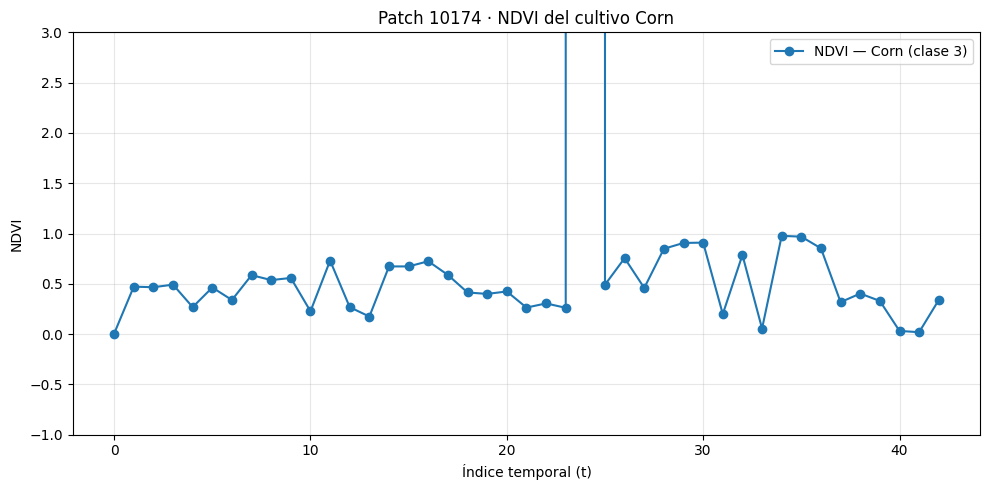

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
id_patch = 10174
CORN_CLASS = 3  # "Corn"

# --- Carga del patch ---
root = '../PASTIS/PASTIS/'
s2     = np.load(f'{root}DATA_S2/S2_{id_patch}.npy')          # (T, C, H, W)
target = np.load(f'{root}ANNOTATIONS/TARGET_{id_patch}.npy')  # target[0]=semantic
semantic = target[0].astype(int)

T, C, H, W = s2.shape
print(f'Patch {id_patch} | S2 shape: (T={T}, C={C}, H={H}, W={W})')

# --- Bandas (ORDER_10) ---
# [B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12] -> 0..9
B4, B8 = 2, 6  # Red, NIR

def safe_norm(a, b):
    return (a - b) / (a + b + 1e-9)

# --- NDVI para la clase Corn (promedio espacial en la clase) ---
mask_corn = (semantic == CORN_CLASS)
if not mask_corn.any():
    print("Este patch no contiene píxeles de la clase 'Corn' (3).")
else:
    ndvi_corn = []
    for t in range(T):
        red = s2[t, B4].astype(float)
        nir = s2[t, B8].astype(float)
        ndvi_img = safe_norm(nir, red)
        ndvi_corn.append(ndvi_img[mask_corn].mean())
    ndvi_corn = np.array(ndvi_corn)

    # --- Gráfica ---
    x = np.arange(T)
    plt.figure(figsize=(10,5))
    plt.plot(x, ndvi_corn, marker='o', label='NDVI — Corn (clase 3)')
    plt.xlabel('Índice temporal (t)')
    plt.ylabel('NDVI')
    plt.title(f'Patch {id_patch} · NDVI del cultivo Corn')
    plt.grid(alpha=0.3)
    plt.ylim(-1, 3)
    plt.legend()
    plt.tight_layout()
    plt.show()





Patch 10174 | S2 shape: (T=43, C=10, H=128, W=128)


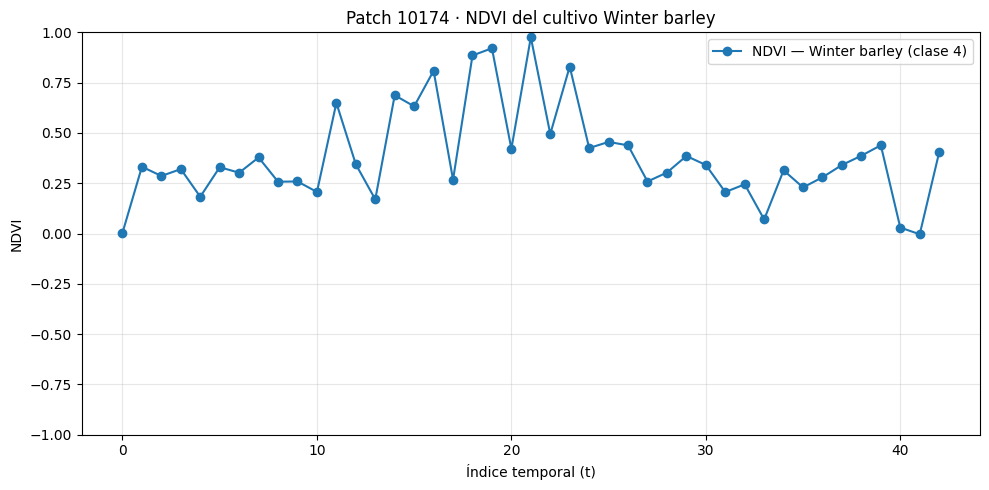

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
id_patch = 10174
WINTER_BARLEY = 4  # clase "Winter barley"

# --- Carga del patch ---
root = '../PASTIS/PASTIS/'
s2     = np.load(f'{root}DATA_S2/S2_{id_patch}.npy')          # (T, C, H, W)
target = np.load(f'{root}ANNOTATIONS/TARGET_{id_patch}.npy')  # target[0]=semantic
semantic = target[0].astype(int)

T, C, H, W = s2.shape
print(f'Patch {id_patch} | S2 shape: (T={T}, C={C}, H={H}, W={W})')

# --- Bandas (ORDER_10) ---
# [B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12] -> 0..9
B4, B8 = 2, 6  # RED, NIR

def ndvi_valid(nir, red, eps=1e-6):
    """NDVI con máscara de validez y recorte a [-1, 1]."""
    nir = nir.astype(float); red = red.astype(float)
    valid = np.isfinite(nir) & np.isfinite(red) & (nir >= 0) & (red >= 0) & ((nir + red) > eps)
    out = np.full_like(nir, np.nan, dtype=float)
    out[valid] = (nir[valid] - red[valid]) / (nir[valid] + red[valid])
    np.clip(out, -1.0, 1.0, out=out)
    return out

# --- NDVI para Winter barley (promedio espacial en la clase por t) ---
mask_wb = (semantic == WINTER_BARLEY)

if not mask_wb.any():
    print("Este patch no contiene píxeles de la clase 'Winter barley' (4).")
else:
    ndvi_wb = []
    for t in range(T):
        red = s2[t, B4]
        nir = s2[t, B8]
        ndvi_img = ndvi_valid(nir, red)           # << usa versión con máscara + clip
        ndvi_wb.append(np.nanmean(ndvi_img[mask_wb]))
    ndvi_wb = np.array(ndvi_wb)

    # --- Gráfica ---
    x = np.arange(T)
    plt.figure(figsize=(10,5))
    plt.plot(x, ndvi_wb, marker='o', label='NDVI — Winter barley (clase 4)')
    plt.xlabel('Índice temporal (t)')
    plt.ylabel('NDVI')
    plt.title(f'Patch {id_patch} · NDVI del cultivo Winter barley')
    plt.grid(alpha=0.3)
    plt.ylim(-1, 1)  # rango físico
    plt.legend()
    plt.tight_layout()
    plt.show()


Patch 10174 | S2 shape: (T=43, C=10, H=128, W=128)


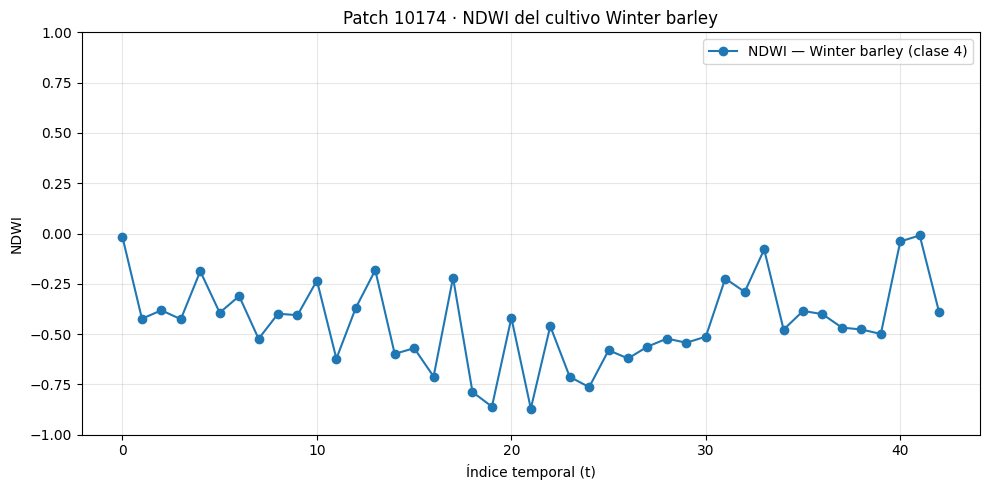

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
id_patch = 10174
WINTER_BARLEY = 4  # clase "Winter barley"

# --- Carga del patch ---
root = '../PASTIS/PASTIS/'
s2     = np.load(f'{root}DATA_S2/S2_{id_patch}.npy')          # (T, C, H, W)
target = np.load(f'{root}ANNOTATIONS/TARGET_{id_patch}.npy')  # target[0]=semantic
semantic = target[0].astype(int)

T, C, H, W = s2.shape
print(f'Patch {id_patch} | S2 shape: (T={T}, C={C}, H={H}, W={W})')

# --- Bandas (ORDER_10) ---
# [B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12] -> 0..9
B3, B8 = 1, 6  # GREEN, NIR

def ndwi_valid(green, nir, eps=1e-6):
    """NDWI con máscara de validez y recorte a [-1, 1]."""
    green = green.astype(float); nir = nir.astype(float)
    valid = np.isfinite(green) & np.isfinite(nir) & (green >= 0) & (nir >= 0) & ((green + nir) > eps)
    out = np.full_like(green, np.nan, dtype=float)
    out[valid] = (green[valid] - nir[valid]) / (green[valid] + nir[valid])
    np.clip(out, -1.0, 1.0, out=out)
    return out

# --- NDWI para Winter barley (promedio espacial en la clase por t) ---
mask_wb = (semantic == WINTER_BARLEY)

if not mask_wb.any():
    print("Este patch no contiene píxeles de la clase 'Winter barley' (4).")
else:
    ndwi_wb = []
    for t in range(T):
        green = s2[t, B3]
        nir   = s2[t, B8]
        ndwi_img = ndwi_valid(green, nir)
        ndwi_wb.append(np.nanmean(ndwi_img[mask_wb]))
    ndwi_wb = np.array(ndwi_wb)

    # --- Gráfica ---
    x = np.arange(T)
    plt.figure(figsize=(10,5))
    plt.plot(x, ndwi_wb, marker='o', label='NDWI — Winter barley (clase 4)')
    plt.xlabel('Índice temporal (t)')
    plt.ylabel('NDWI')
    plt.title(f'Patch {id_patch} · NDWI del cultivo Winter barley')
    plt.grid(alpha=0.3)
    plt.ylim(-1, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
